Files loaded successfully.
Assessments shape: (13, 6)
Courses shape: (4, 3)

Column types:
score: int64
attendance_pct: int64

Duplicate rows removed: 1
Merged rows: 12
Exactly 12 rows confirmed.
No unmatched course_id confirmed.

P1 completed successfully.

Pass flag created.
   department  total_assessments  passing_count  pass_rate_pct
0    Business                  6              5      83.333333
1  Technology                  6              3      50.000000
Course ID: C4
Passing count (numerator): 1
Total assessments (denominator): 3
Pass rate: 33.33 %

P2 completed successfully.
month
Jan    55.00
Feb    62.75
Mar    66.75
Name: score, dtype: float64


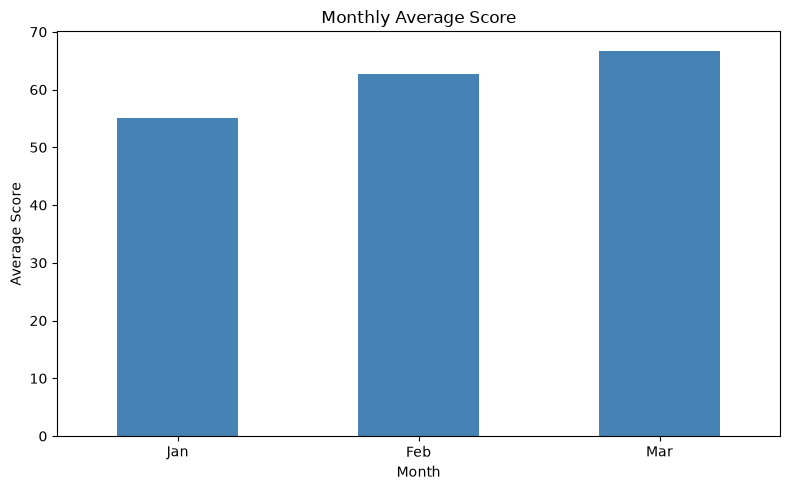

✓ outputs/clean_data.csv
✓ outputs/python_summary.csv
✓ outputs/python_chart.png


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path




Path("outputs").mkdir(parents=True, exist_ok=True)


assessments = pd.read_csv("data1.csv")
courses = pd.read_csv("courses.csv")

print("Files loaded successfully.")
print("Assessments shape:", assessments.shape)
print("Courses shape:", courses.shape)



assessments["score"] = pd.to_numeric(
    assessments["score"],
    errors="coerce"
)

assessments["attendance_pct"] = pd.to_numeric(
    assessments["attendance_pct"],
    errors="coerce"
)

print("\nColumn types:")
print("score:", assessments["score"].dtype)
print("attendance_pct:", assessments["attendance_pct"].dtype)



before = len(assessments)

assessments = assessments.drop_duplicates()

after = len(assessments)

print("\nDuplicate rows removed:", before - after)



merged = assessments.merge(
    courses,
    on="course_id",
    how="left"
)

print("Merged rows:", len(merged))


# Assertions
assert len(merged) == 12, (
    f"Expected 12 rows, but got {len(merged)}"
)

assert merged["department"].isna().sum() == 0, (
    "Some course_id values were not matched."
)

print("Exactly 12 rows confirmed.")
print("No unmatched course_id confirmed.")

print("\nP1 completed successfully.")



merged["pass_flag"] = (
    merged["score"] >= 50
).astype(int)

print("\nPass flag created.")



department_summary = (
    merged
    .groupby("department")
    .agg(
        total_assessments=("score", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)


department_summary["pass_rate_pct"] = (
    department_summary["passing_count"]
    / department_summary["total_assessments"]
    * 100
)


print(department_summary)



course_summary = (
    merged
    .groupby("course_id")
    .agg(
        total_assessments=("score", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)

course_summary["pass_rate_pct"] = (
    course_summary["passing_count"]
    / course_summary["total_assessments"]
    * 100
)



lowest_course = course_summary.loc[
    course_summary["pass_rate_pct"].idxmin()
]


print("Course ID:",
      lowest_course["course_id"])

print("Passing count (numerator):",
      int(lowest_course["passing_count"]))

print("Total assessments (denominator):",
      int(lowest_course["total_assessments"]))

print("Pass rate:",
      round(lowest_course["pass_rate_pct"], 2),
      "%")

print("\nP2 completed successfully.")


month_order = ["Jan", "Feb", "Mar"]

merged["month"] = pd.Categorical(
    merged["month"],
    categories=month_order,
    ordered=True
)



monthly_avg = (
    merged
    .groupby("month", observed=False)["score"]
    .mean()
    .reindex(month_order)
)

print(monthly_avg)


# Create chart
plt.figure(figsize=(8, 5))

monthly_avg.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Monthly Average Score")
plt.xlabel("Month")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()


plt.savefig(
    "outputs/python_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



merged.to_csv(
    "outputs/clean_data.csv",
    index=False
)


department_summary.to_csv(
    "outputs/python_summary.csv",
    index=False
)


print("✓ outputs/clean_data.csv")
print("✓ outputs/python_summary.csv")
print("✓ outputs/python_chart.png")
